In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.colors as mcolors

In [3]:
path = r'C:\Users\ndematos\Desktop\REED_scenarios'
df = pd.DataFrame()
for dir in os.listdir(path):
    if '.csv' in dir:
        #result_path = os.path.join(path, dir, 'Output', 'post_process_planning', 'Nodal_summary_planning.csv')
        result_path = os.path.join(path, dir)
        data = pd.read_csv(result_path)
        #data.loc[:, 'Scenario'] = dir
        df = pd.concat([df, data])
# scenario_rename = {
#     'REED-no-CER':'No-CER',
#     'REED-no-CER-ITCs':'No-CER-ITCs',
#     'REED-no-ctax':'Emission-Limit',
#     'REED-no-ctax-ITCs':'Emission-Limit-ITCs',
#     'REED-reference':'Reference',
#     'REED-reference-ITCs':'Reference-ITCs'
# }
# df.loc[:, 'Scenario'] = df.Scenario.map(scenario_rename)
df = df[~df.Scenario.str.contains('Emission')]
df = df[df.Time != 'All']
df.loc[:, 'Time'] = df.Time.astype(int)
df

,Model,Scenario,Region,Parameter,Variable,Time,Value,Unit
0,PypsaCAD_v1.4.0,No-CER,AB_Central,Average_Utilization,default_solar_PV,2021,51.000000,%
1,PypsaCAD_v1.4.0,No-CER,AB_Central,Average_Utilization,gas_CC,2021,71.285714,%
2,PypsaCAD_v1.4.0,No-CER,AB_Central,Average_Utilization,hydro_ror,2021,100.000000,%
3,PypsaCAD_v1.4.0,No-CER,AB_Central,Average_Utilization,wind_2021,2021,100.000000,%
4,PypsaCAD_v1.4.0,No-CER,AB_North,Average_Utilization,gas_CC,2021,68.565217,%
...,...,...,...,...,...,...,...,...
4949,PypsaCAD_v1.4.0,Reference,SK,Qualifying_Capacity,hydro_storage,2050,807.500000,MW
4950,PypsaCAD_v1.4.0,Reference,All,Investment_Period_Weighting,planning_model,2021,7.463213,NaN
4951,PypsaCAD_v1.4.0,Reference,All,Investment_Period_Weighting,planning_model,2030,5.226374,NaN
4952,PypsaCAD_v1.4.0,Reference,All,Investment_Period_Weighting,planning_model,2040,3.208540,NaN


In [4]:
# Custom color map
tech_colors = {
    'Natural Gas': '#ff6b6b',
    'Solar PV': '#ffff99',
    'Lithium-ion Battery': '#6a3d9a',
    'Onshore Wind': '#b2df8a',
    'Nuclear': '#ff7f00',
    'Oil': '#ffaa33',
    'Hydro': '#a6cee3',
    'Coal': '#b15928',
    'Biomass': '#33a02c',
    'Diesel': '#000000',
    'Other Combustion': '#b15928',
    'Load Shed': '#000000'
}

tech_map = {
    'default_liion_battery':'Lithium-ion Battery',
    'default_solar_PV': 'Solar PV',
    'gas_CC': 'Natural Gas',
    'gas_CT': 'Natural Gas',
    'wind_new': 'Onshore Wind',
    'default_nuclear': 'Nuclear',
    'default_oil': 'Oil',
    'default_diesel': 'Diesel',
    'hydro_ror': 'Hydro',
    'hydro_storage': 'Hydro',
    'coal_IGCC': 'Coal',
    'default_biogas': 'Biomass',
    'default_biomass': 'Biomass',
    'wind_2021': 'Onshore Wind',
    'load_shedding': 'Load Shed'
}

tech_map_agg = {
    'default_liion_battery':'Lithium-ion Battery',
    'default_solar_PV': 'Solar PV',
    'gas_CC': 'Natural Gas',
    'gas_CT': 'Natural Gas',
    'wind_new': 'Onshore Wind',
    'default_nuclear': 'Nuclear',
    'default_oil': 'Other Combustion',
    'default_diesel': 'Other Combustion',
    'hydro_ror': 'Hydro',
    'hydro_storage': 'Hydro',
    'coal_IGCC': 'Other Combustion',
    'default_biogas': 'Other Combustion',
    'default_biomass': 'Other Combustion',
    'wind_2021': 'Onshore Wind',
    'load_shedding': 'Natural Gas'
}


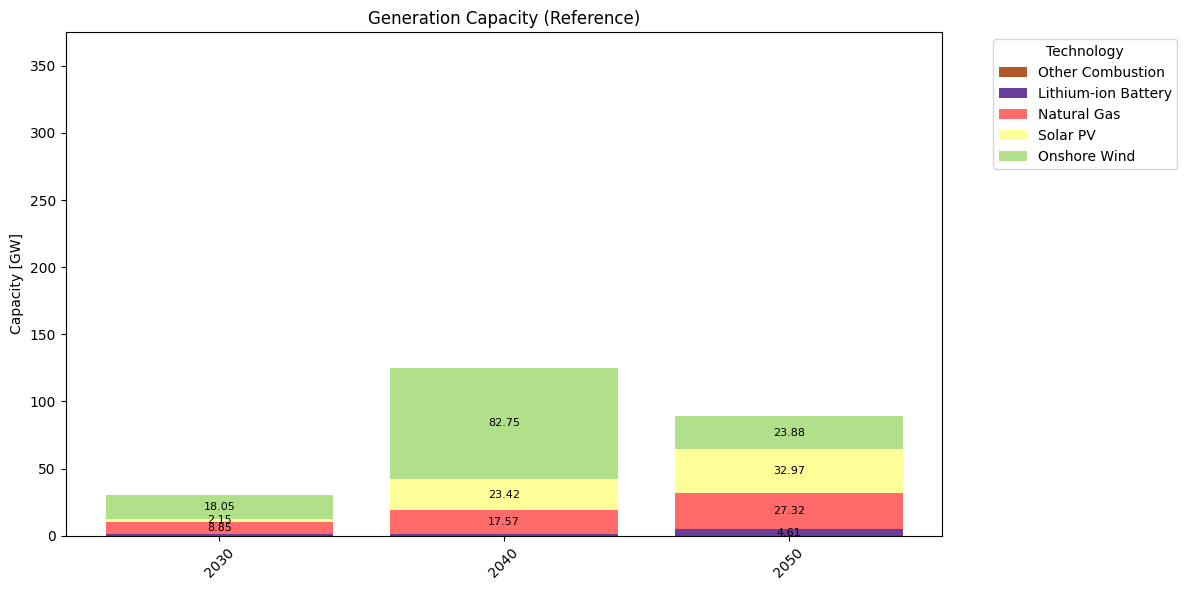

In [6]:
existing_cap = df[(df.Parameter == 'New_Capacity') & (df.Scenario == 'Reference')]
existing_cap.loc[:, 'Value'] = existing_cap.Value / 1000
existing_cap.loc[:, 'Variable'] = existing_cap.Variable.replace(tech_map_agg)
existing_cap.loc[:, 'Scenario'] = 'Existing Capacity 2021'
existing_cap.loc[:, 'Time'] = existing_cap.Time.astype(str)

existing_cap = existing_cap.groupby(['Time', 'Variable'])['Value'].sum()
existing_cap = existing_cap.unstack(level=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
# Compute the range (max - min) for each column
variability = existing_cap.max() - existing_cap.min()

# Sort columns by least variable (smallest change)
sorted_columns = variability.sort_values().index.tolist()

bottom = pd.Series([0] * len(existing_cap), index=existing_cap.index)

for tech in sorted_columns:
    values = existing_cap[tech]
    ax.bar(existing_cap.index, values, bottom=bottom, label=tech, color=tech_colors[tech])
    for idx, (x, height, btm) in enumerate(zip(existing_cap.index, existing_cap[tech], bottom)):
        if height > 2:  # Optional: skip labels for zero height
            ax.text(x, btm + height / 2, f'{height:.2f}', ha='center', va='center', fontsize=8)
    bottom += values

ax.set_ylabel('Capacity [GW]')
ax.set_ylim(0, 375)
ax.set_title('Generation Capacity (Reference)')
ax.legend(title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

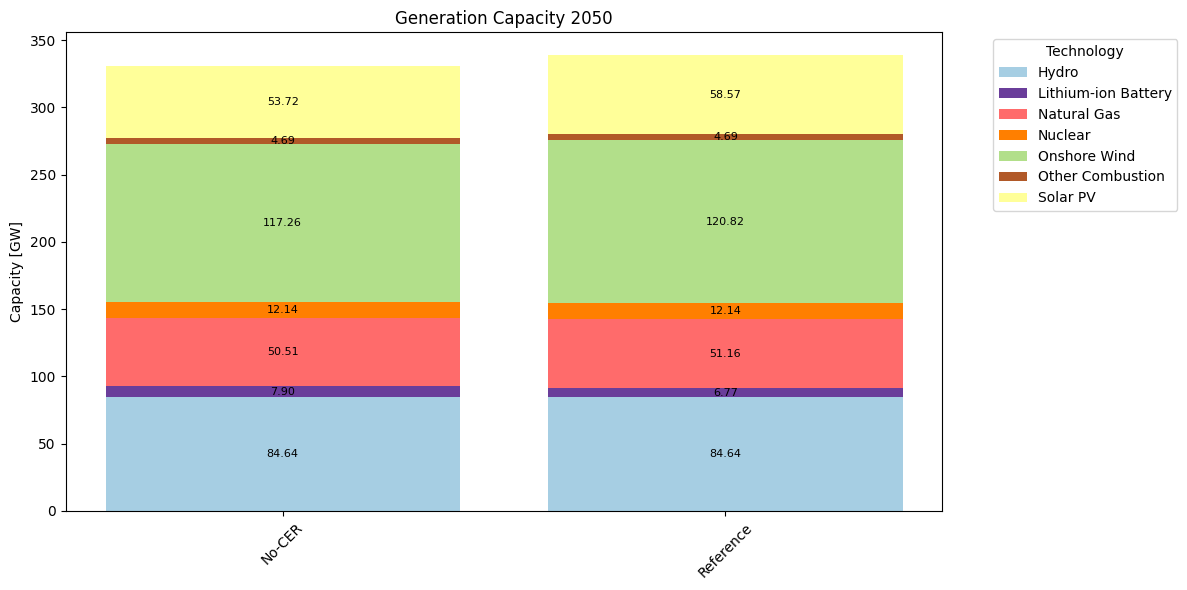

Variable,Hydro,Lithium-ion Battery,Natural Gas,Nuclear,Onshore Wind,Other Combustion,Solar PV
Scenario,,,,,,,
No-CER,84.63833,7.89913,50.51426,12.145,117.25746,4.692,53.72223
Reference,84.63833,6.77109,51.16184,12.145,120.81572,4.692,58.57312


In [177]:
year = 2050
capacity = df[df.Parameter == 'Capacity']
capacity.loc[:, 'Value'] = capacity.Value / 1000
capacity = capacity[capacity.Time == year]
capacity.loc[:, 'Variable'] = capacity.Variable.replace(tech_map_agg)
capacity = capacity.groupby(['Scenario', 'Variable'])['Value'].sum()
capacity = capacity.unstack(level=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

bottom = pd.Series([0] * len(capacity), index=capacity.index)

for tech in capacity.columns:
    values = capacity[tech]
    ax.bar(capacity.index, values, bottom=bottom, label=tech, color=tech_colors[tech])
    for idx, (x, height, btm) in enumerate(zip(capacity.index, capacity[tech], bottom)):
        if height > 0.005:  # Optional: skip labels for zero height
            ax.text(x, btm + height / 2, f'{height:.2f}', ha='center', va='center', fontsize=8)
    bottom += values

ax.set_ylabel('Capacity [GW]')
ax.set_title(f'Generation Capacity {year}')
ax.legend(title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
capacity

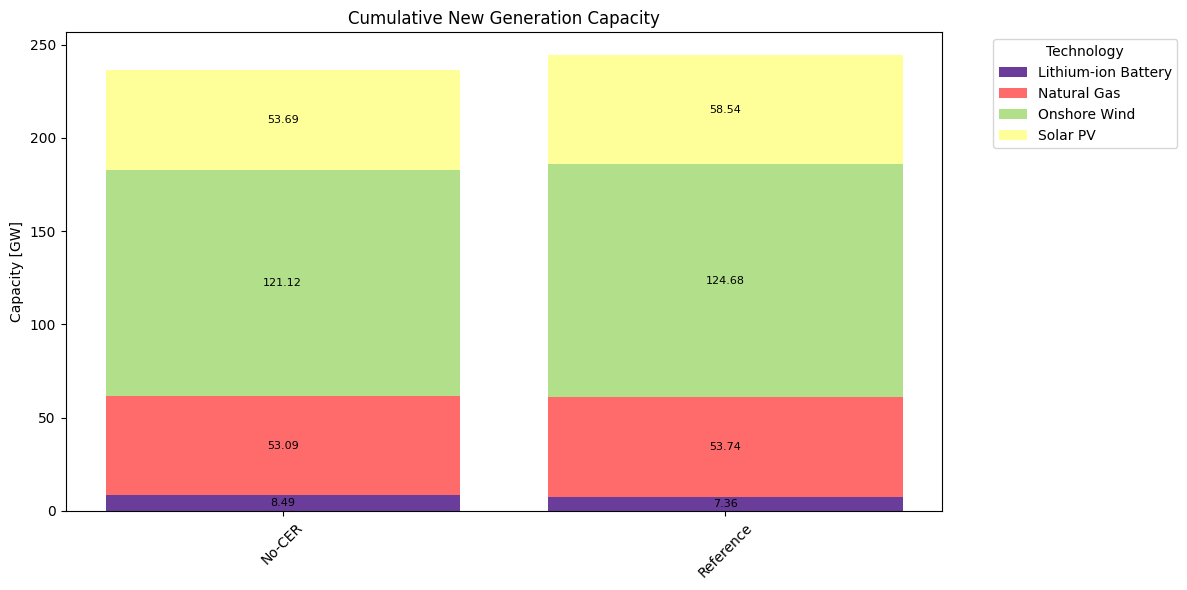

In [159]:
new_capacity = df[df.Parameter == 'New_Capacity']
new_capacity.loc[:, 'Value'] = new_capacity.Value / 1000
new_capacity = new_capacity[~new_capacity.Variable.isin(['default_biomass'])]
new_capacity.loc[:, 'Variable'] = new_capacity.Variable.replace(tech_map)
new_capacity = new_capacity.groupby(['Scenario', 'Variable'])['Value'].sum()
new_capacity = new_capacity.unstack(level=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

bottom = pd.Series([0] * len(new_capacity), index=new_capacity.index)

for tech in new_capacity.columns:
    values = new_capacity[tech]
    ax.bar(new_capacity.index, values, bottom=bottom, label=tech, color=tech_colors[tech])
    for idx, (x, height, btm) in enumerate(zip(new_capacity.index, new_capacity[tech], bottom)):
        if height > 0.005:  # Optional: skip labels for zero height
            ax.text(x, btm + height / 2, f'{height:.2f}', ha='center', va='center', fontsize=8)
    bottom += values

ax.set_ylabel('Capacity [GW]')
ax.set_title('Cumulative New Generation Capacity')
ax.legend(title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

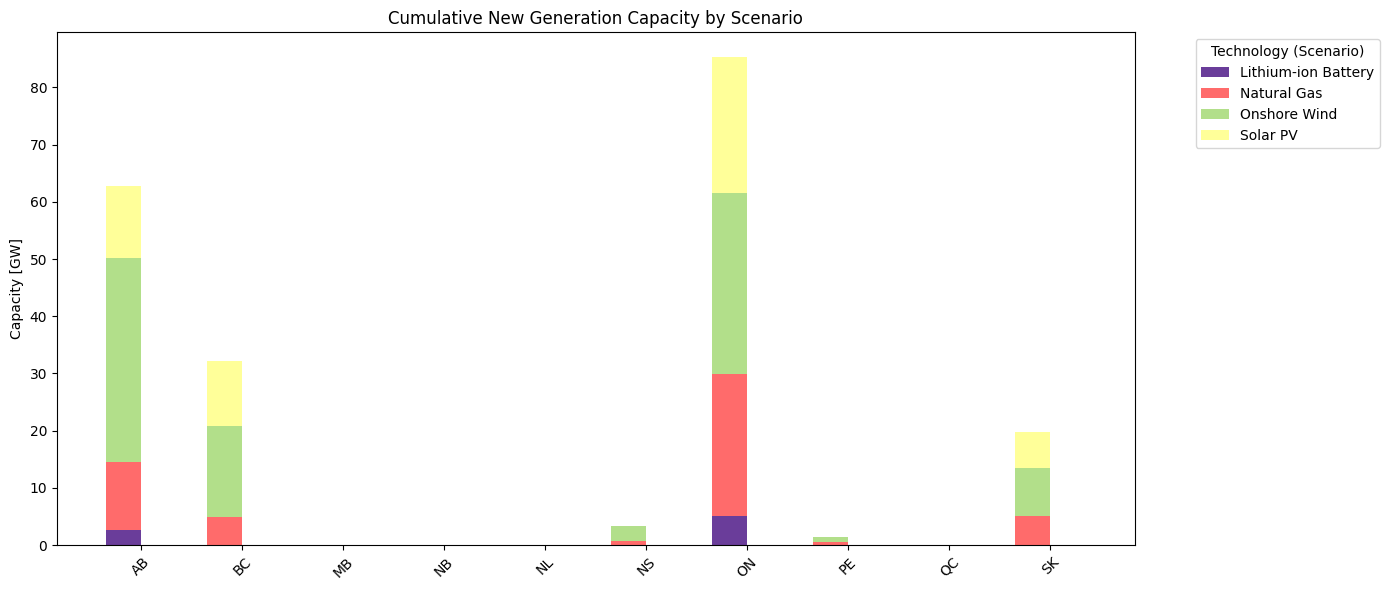

In [142]:
# Define the scenarios you want to compare
scenarios = ["Reference", "Reference-Wrong_Nuclear"]

# Store processed data in a dictionary
all_data = {}

for scenario in scenarios:
    new_capacity = df[df.Parameter == 'New_Capacity']
    new_capacity = new_capacity[new_capacity.Scenario == scenario]
    new_capacity = new_capacity[~new_capacity.Variable.isin(['default_biomass'])]
    new_capacity.loc[:, 'Value'] = new_capacity.Value / 1000
    new_capacity.loc[:, 'Variable'] = new_capacity.Variable.replace(tech_map)
    new_capacity.loc[:, 'Region'] = new_capacity.Region.str[:2]
    
    grouped = new_capacity.groupby(['Region', 'Variable'])['Value'].sum().unstack(level=1)
    all_data[scenario] = grouped

# Get list of all regions and technologies
all_regions = sorted(set().union(*[df.index for df in all_data.values()]))
all_techs = sorted(set().union(*[df.columns for df in all_data.values()]))

# Plotting
fig, ax = plt.subplots(figsize=(14, 6))

bar_width = 0.35
x = np.arange(len(all_regions))  # Numeric x for region positions

plotted_techs = set()

for i, scenario in enumerate(scenarios):
    data = all_data[scenario].reindex(index=all_regions, columns=all_techs, fill_value=0)
    bottom = np.zeros(len(all_regions))

    for tech in all_techs:
        values = data[tech].values
        x_pos = x + (i - 0.5) * bar_width

        # Only label once per technology
        label = tech if tech not in plotted_techs else None
        ax.bar(x_pos, values, bar_width, bottom=bottom, label=label, color=tech_colors.get(tech, 'grey'))
        bottom += values

        plotted_techs.add(tech)

# Final touches
ax.set_xticks(x)
ax.set_xticklabels(all_regions, rotation=45)
ax.set_ylabel('Capacity [GW]')
ax.set_title('Cumulative New Generation Capacity by Scenario')
ax.legend(title='Technology (Scenario)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

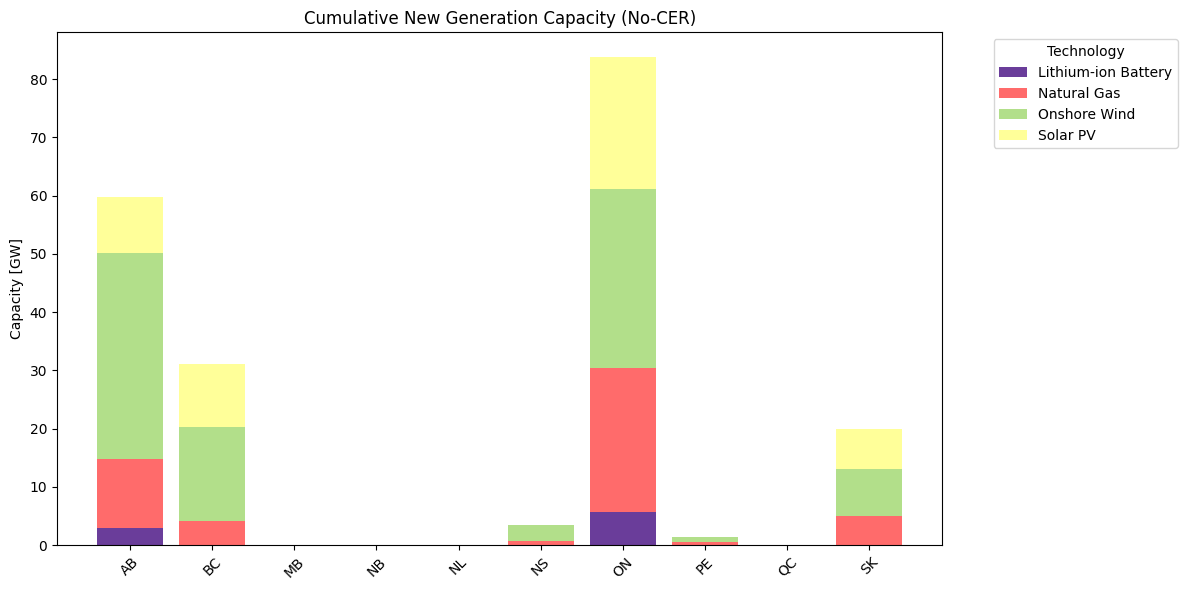

In [9]:
scenario = "No-CER"
new_capacity = df[df.Parameter == 'New_Capacity']
new_capacity = new_capacity[new_capacity.Scenario == scenario]
new_capacity.loc[:, 'Value'] = new_capacity.Value / 1000
new_capacity = new_capacity[~new_capacity.Variable.isin(['default_biomass'])]
new_capacity.loc[:, 'Variable'] = new_capacity.Variable.replace(tech_map)
new_capacity.loc[:, 'Region'] = new_capacity.Region.str[:2]
new_capacity = new_capacity.groupby(['Region', 'Variable'])['Value'].sum()
new_capacity = new_capacity.unstack(level=1)

fig, ax = plt.subplots(figsize=(12, 6))

bottom = pd.Series([0] * len(new_capacity), index=new_capacity.index)

for tech in new_capacity.columns:
    values = new_capacity[tech]
    ax.bar(new_capacity.index, values, bottom=bottom, label=tech, color=tech_colors[tech])
    bottom += values

ax.set_ylabel('Capacity [GW]')
ax.set_title(f'Cumulative New Generation Capacity ({scenario})')
ax.legend(title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

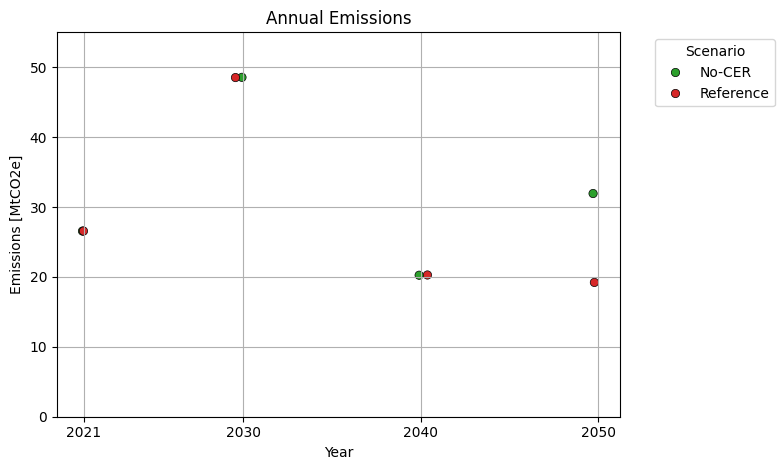

,Time,Scenario,Value,x_jitter
0,2021,No-CER,26.564862,2020.933953
1,2030,No-CER,48.557628,2029.924702
2,2040,No-CER,20.244793,2039.915287
3,2050,No-CER,31.937142,2049.721335
4,2021,Reference,26.564862,2020.987623
5,2030,Reference,48.530272,2029.559628
6,2040,Reference,20.279781,2040.381468
7,2050,Reference,19.215217,2049.796110


In [181]:
emissions = df[df.Parameter == 'Emissions']
emissions = emissions[~emissions.Scenario.str.contains('ITC')]

emissions = emissions.groupby(['Scenario', 'Time'])['Value'].sum()
emissions = emissions.unstack(level=1)
df_long = emissions.T.reset_index().melt(id_vars='Time', var_name='Scenario', value_name='Value')
df_long = df_long.rename(columns={'index': 'Year'})
df_long.loc[:, 'Value'] = df_long.Value / 1000000
df_long['x_jitter'] = df_long['Time'] + np.random.uniform(-0.5, 0.5, size=len(df_long))


base_colors = {
    'Emission_limit': '#1f77b4',  # blue
    'No-CER': '#2ca02c',          # green
    'Reference': '#d62728',       # red
    'Reference-reduce_hydro': '#000000',
    'No-CER-Wrong_Nuclear': '#1f77b4',
    'Reference-Wrong_Nuclear': '#1f77b4',
}
def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return mcolors.to_hex([min(1, c_i + (1 - c_i) * amount) for c_i in c])

scenario_colors = {}
for scenario in base_colors:
    scenario_colors[scenario] = base_colors[scenario]
    scenario_colors[f'{scenario}-ITCs'] = lighten_color(base_colors[scenario], amount=0.5)

sns.scatterplot(df_long, x='x_jitter', y='Value', hue='Scenario', palette=scenario_colors, edgecolor='black', linewidth=0.5)
#sns.lineplot(data=df_long, x='x_jitter', y='Value', hue='Scenario', palette=scenario_colors, legend=False, alpha=0.8)
plt.xticks([2021, 2030, 2040, 2050])
plt.ylim([0, 55])
plt.xlabel('Year')
plt.ylabel('Emissions [MtCO2e]')
plt.title('Annual Emissions')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
df_long

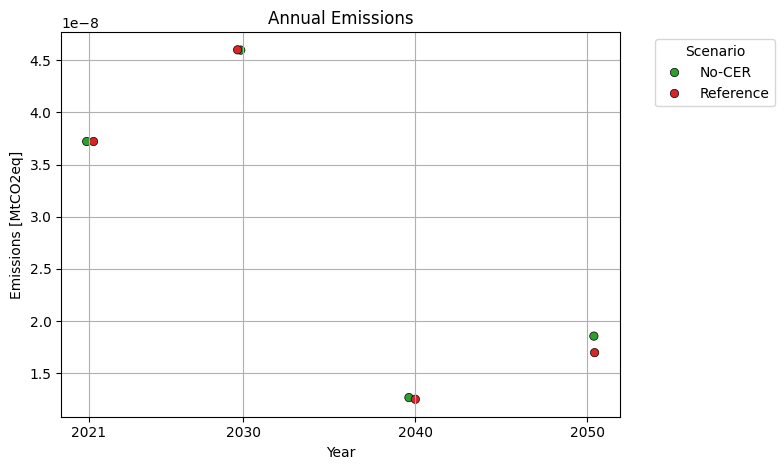

In [11]:
generation = df[df.Parameter == 'Annual_Generation']
total_generation = generation.copy().groupby(['Scenario', 'Time'])['Value'].sum()

emissions = df[df.Parameter == 'Emissions']
emissions = emissions.groupby(['Scenario', 'Time'])['Value'].sum()
emissions = emissions.divide(total_generation)
emissions = emissions.unstack(level=1)
df_long = emissions.T.reset_index().melt(id_vars='Time', var_name='Scenario', value_name='Value')
df_long = df_long.rename(columns={'index': 'Year'})
df_long.loc[:, 'Value'] = df_long.Value / 1000000
df_long['x_jitter'] = df_long['Time'] + np.random.uniform(-0.5, 0.5, size=len(df_long))


base_colors = {
    'Emission_limit': '#1f77b4',  # blue
    'No_CER': '#2ca02c',          # green
    'Reference': '#d62728',       # red
}

sns.scatterplot(df_long, x='x_jitter', y='Value', hue='Scenario', palette=scenario_colors, edgecolor='black', linewidth=0.5)
#sns.lineplot(data=df_long, x='x_jitter', y='Value', hue='Scenario', palette=scenario_colors, legend=False, alpha=0.8)
plt.xticks([2021, 2030, 2040, 2050])
plt.xlabel('Year')
plt.ylabel('Emissions [MtCO2eq]')
plt.title('Annual Emissions')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [169]:
transmission = df[(df.Parameter == 'Transmission_Capacity') & (df.Time == 2050)]
transmission = transmission.groupby(['Scenario', 'Region'])['Value'].sum()

inter_lines = {
'NL_Newfoundland->NS_East':'NL<->NS',
'MB->ON_Northwest':'MB<->ON',
'BC_South->AB_South':'BC<->AB',
'AB_South->SK':'AB<->SK',
'QC_East->NB_West':'QC<->NB',
'ON_East->QC_South':'ON<->QC',
'SK->MB':'SK<->MB',
'NL_Labrador->QC_Central':'NL<->QC',
'NB_East->NS_West':'NB<->NS',
}
intra_lines = [
'ON_South->ON_Toronto', 
'QC_North->QC_East',
'QC_North->QC_Central',
'ON_Northwest->ON_North',
'AB_South->AB_Central',
'AB_Central->AB_North',
'ON_North->ON_East'
]
new_transmission = df[df.Parameter == 'New_Transmission_Capacity']

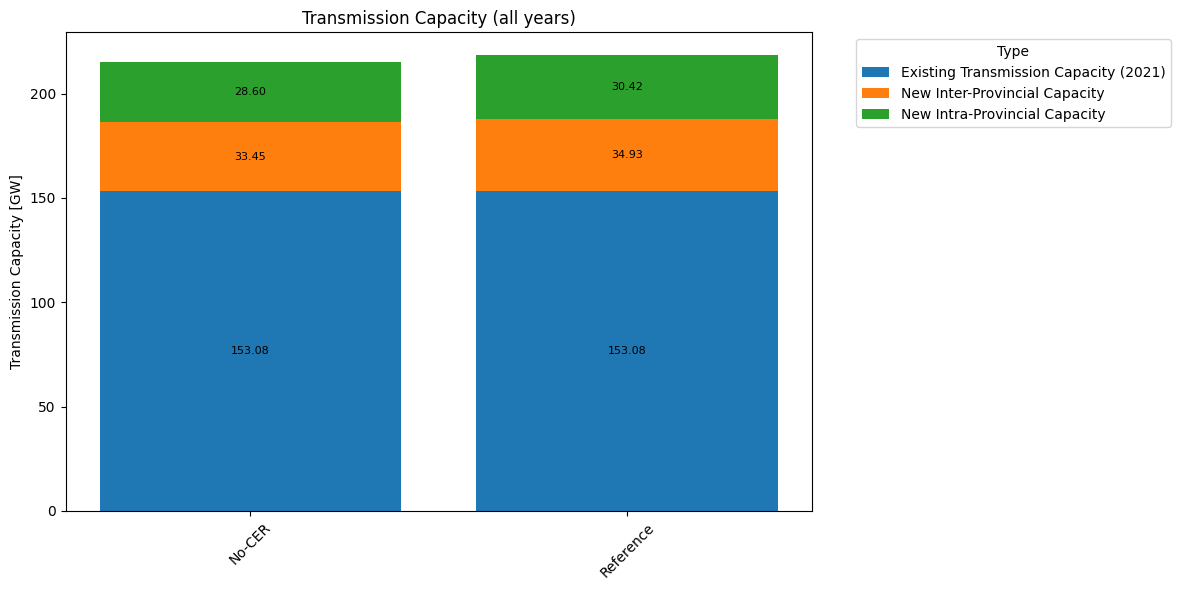

In [170]:
existing_trans = df[(df.Parameter == 'Transmission_Capacity') & (df.Time == 2021)]
existing_trans.loc[:, 'Variable'] = 'Existing Transmission Capacity (2021)'

new_transmission_intra = new_transmission[new_transmission.Region.isin(intra_lines)]
new_transmission_intra.loc[:, 'Variable'] = 'New Intra-Provincial Capacity'
new_transmission_inter = new_transmission[new_transmission.Region.isin(inter_lines.keys())]
new_transmission_inter.loc[:, 'Variable'] = 'New Inter-Provincial Capacity'
new_t = pd.concat([new_transmission_inter, new_transmission_intra, existing_trans])
new_t.loc[:, 'Value'] = new_t.Value / 1000
new_t = new_t.groupby(['Scenario', 'Variable'])['Value'].sum()
new_t = new_t.unstack(level=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

bottom = [0] * len(new_t)

for col in new_t.columns:
    ax.bar(new_t.index, new_t[col], bottom=bottom, label=col)
    # Add text annotations to each bar segment
    for idx, (x, height, btm) in enumerate(zip(new_t.index, new_t[col], bottom)):
        if height > 0:  # Optional: skip labels for zero height
            ax.text(x, btm + height / 2, f'{height:.2f}', ha='center', va='center', fontsize=8)

    bottom = [i+j for i,j in zip(bottom, new_t[col])]

ax.set_ylabel('Transmission Capacity [GW]')
ax.set_title('Transmission Capacity (all years)')
plt.xticks(rotation=45)
ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

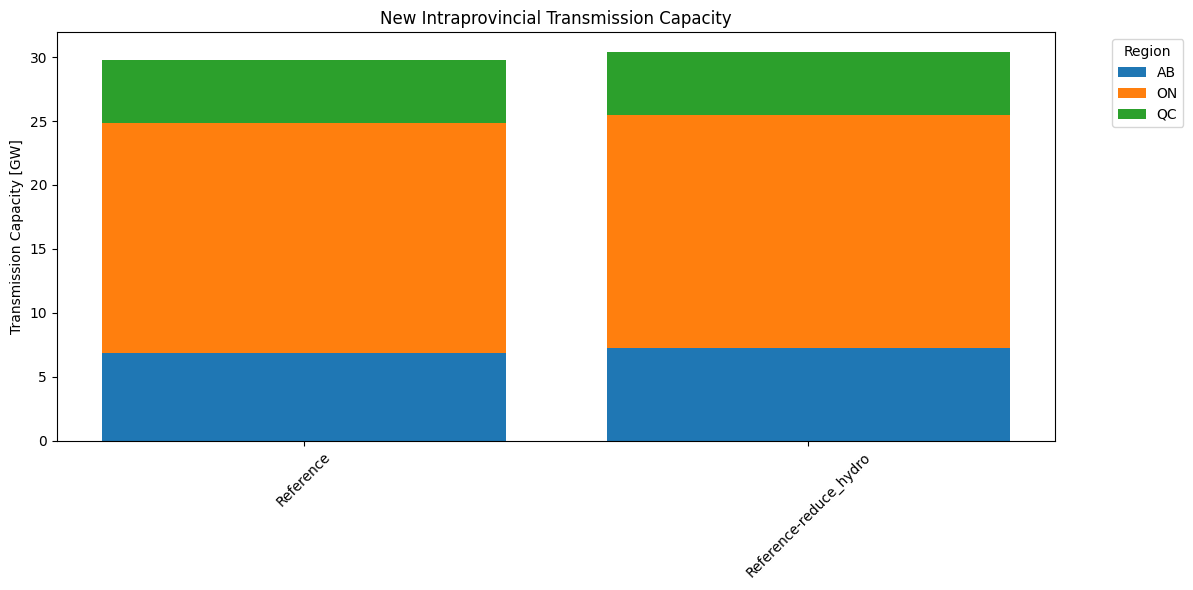

In [147]:
new_transmission_intra = new_transmission[new_transmission.Region.isin(intra_lines)]
new_transmission_intra.loc[:, 'Region'] = new_transmission_intra.Region.str[:2]
new_transmission_intra.loc[:, 'Value'] = new_transmission_intra.Value / 1000
new_transmission_intra = new_transmission_intra.groupby(['Scenario', 'Region'])['Value'].sum()
new_transmission_intra = new_transmission_intra.unstack(level=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

bottom = [0] * len(new_transmission_intra)

for col in new_transmission_intra.columns:
    ax.bar(new_transmission_intra.index, new_transmission_intra[col], bottom=bottom, label=col)
    
    bottom = [i+j for i,j in zip(bottom, new_transmission_intra[col])]

ax.set_ylabel('Transmission Capacity [GW]')
ax.set_title('New Intraprovincial Transmission Capacity')
plt.xticks(rotation=45)
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

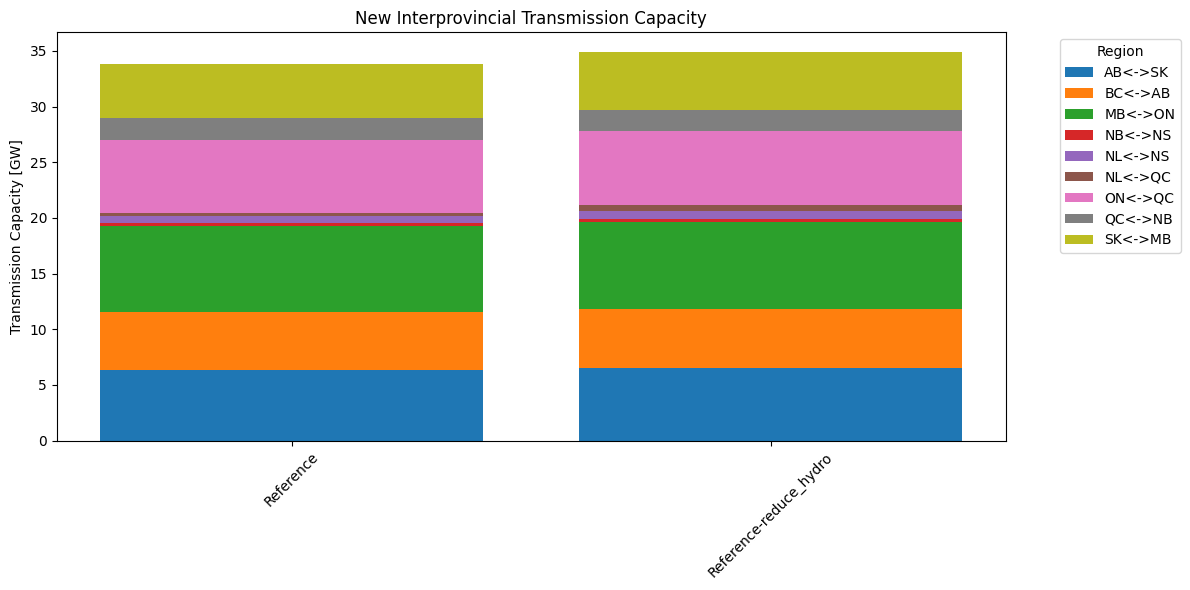

In [148]:
new_transmission_inter = new_transmission[new_transmission.Region.isin(inter_lines.keys())]
new_transmission_inter.loc[:, 'Region'] = new_transmission_inter.Region.map(inter_lines)
new_transmission_inter.loc[:, 'Value'] = new_transmission_inter.Value / 1000
new_transmission_inter = new_transmission_inter.groupby(['Scenario', 'Region'])['Value'].sum()
new_transmission_inter = new_transmission_inter.unstack(level=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

bottom = [0] * len(new_transmission_inter)

for col in new_transmission_inter.columns:
    ax.bar(new_transmission_inter.index, new_transmission_inter[col], bottom=bottom, label=col)
    bottom = [i+j for i,j in zip(bottom, new_transmission_inter[col])]

ax.set_ylabel('Transmission Capacity [GW]')
ax.set_title('New Interprovincial Transmission Capacity')
plt.xticks(rotation=45)
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

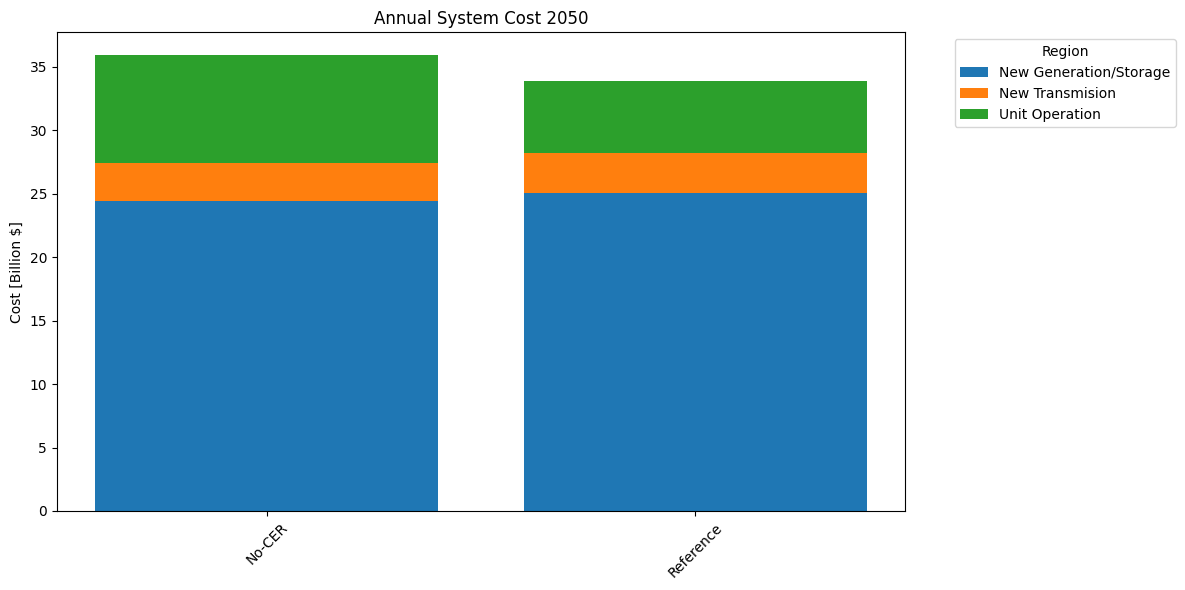

Parameter,New Generation/Storage,New Transmision,Unit Operation
Scenario,,,
No-CER,24.446075,2.961114,8.525922
Reference,25.082296,3.131538,5.659712


In [180]:
costs = df[df.Parameter.isin(['Total_Capex', 'Total_Capex_Transmission', 'Generator_Opex'])]
costs.loc[:, 'Region'] = costs.Region.str[:2]
costs = costs[costs.Time == 2050]
costs.loc[:, 'Value'] = costs.Value / 1000000000
costs = costs.groupby(['Scenario', 'Parameter'])['Value'].sum()
costs = costs.unstack(level=1).fillna(0)
costs = costs.rename(columns={'Total_Capex': 'New Generation/Storage', 'Total_Capex_Transmission': 'New Transmision'})
costs['Unit Operation'] = costs.Generator_Opex #+ costs.Storage_Opex
costs = costs.drop(['Generator_Opex'], axis=1)
fig, ax = plt.subplots(figsize=(12, 6))

bottom = [0] * len(costs)

for col in costs.columns:
    ax.bar(costs.index, costs[col], bottom=bottom, label=col)
    bottom = [i+j for i,j in zip(bottom, costs[col])]

ax.set_ylabel('Cost [Billion $]')
ax.set_title('Annual System Cost 2050')
plt.xticks(rotation=45)
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
costs

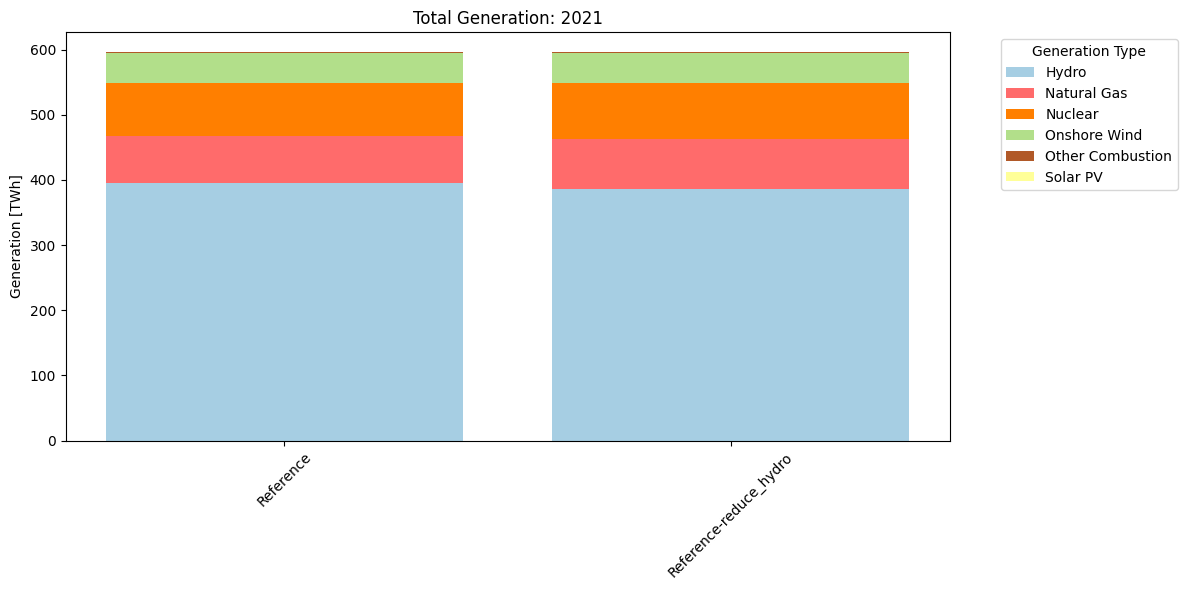

In [150]:
year = 2021
generation = df[df.Parameter == 'Annual_Generation']
generation.loc[:, 'Variable'] = generation.Variable.map(tech_map_agg)
#generation.loc[:, 'Region'] = generation.Region.str[:2]
generation = generation[generation.Time == year]
generation.loc[:, 'Value'] = generation.Value / 1000000
generation = generation.groupby(['Scenario', 'Variable'])['Value'].sum()
generation = generation.unstack(level=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

bottom = [0] * len(generation)

for col in generation.columns:
    ax.bar(generation.index, generation[col], bottom=bottom, label=col, color=tech_colors[col])
    bottom = [i+j for i,j in zip(bottom, generation[col])]

ax.set_ylabel('Generation [TWh]')
ax.set_title(f'Total Generation: {year}')
plt.xticks(rotation=45)
ax.legend(title='Generation Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

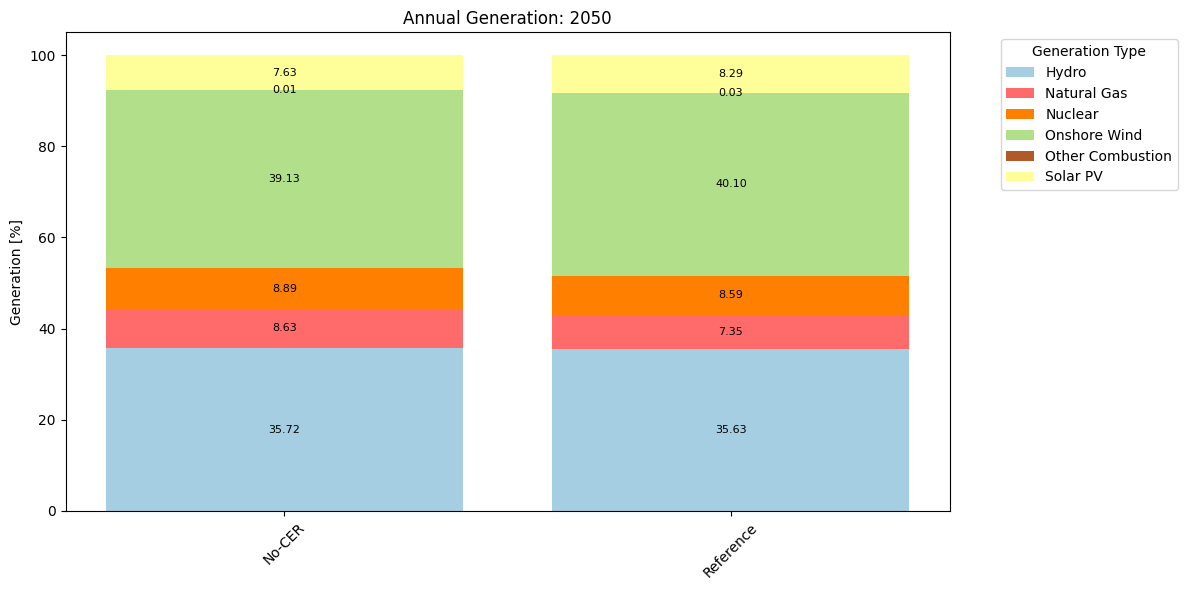

In [167]:
year = 2050
generation = df[df.Parameter == 'Annual_Generation']
generation.loc[:, 'Variable'] = generation.Variable.replace(tech_map_agg)
generation.loc[:, 'Region'] = generation.Region.str[:2]
generation = generation[generation.Time == year]

total_generation = generation.copy().groupby('Scenario')['Value'].sum()
total_generation.name = 'total_gen'
generation = generation.merge(total_generation, how='left', left_on='Scenario', right_index=True)
generation.loc[:, 'Value'] = generation.Value.divide(generation.total_gen) * 100
#generation = generation[generation.Scenario == 'Reference']
generation = generation.groupby(['Scenario', 'Variable'])['Value'].sum()
generation = generation.unstack(level=1).fillna(0)


fig, ax = plt.subplots(figsize=(12, 6))

bottom = [0] * len(generation)

for col in generation.columns:
    ax.bar(generation.index, generation[col], bottom=bottom, label=col, color=tech_colors[col])
    for idx, (x, height, btm) in enumerate(zip(generation.index, generation[col], bottom)):
        if height > 0.005:  # Optional: skip labels for zero height
            ax.text(x, btm + height / 2, f'{height:.2f}', ha='center', va='center', fontsize=8)
    bottom = [i+j for i,j in zip(bottom, generation[col])]

ax.set_ylabel('Generation [%]')
ax.set_title(f'Annual Generation: {year}')
plt.xticks(rotation=45)
ax.legend(title='Generation Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

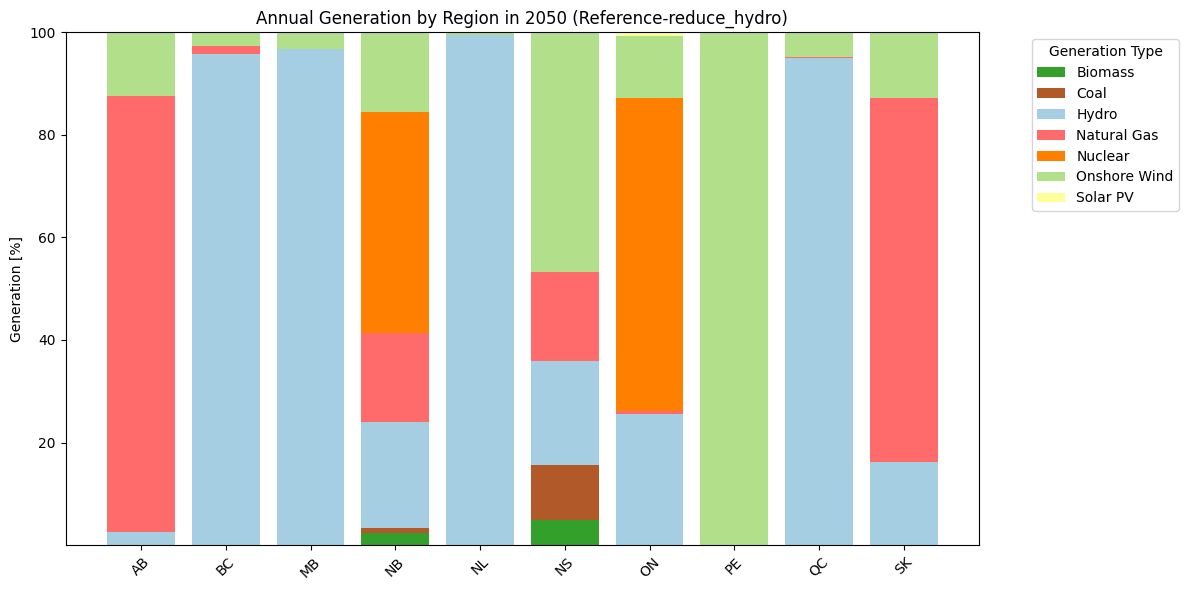

In [116]:
year = 2021
scenario = 'Reference-reduce_hydro'
generation = df[df.Parameter == 'Annual_Generation']
generation = generation[generation.Scenario == scenario]
generation.loc[:, 'Variable'] = generation.Variable.map(tech_map)
generation.loc[:, 'Region'] = generation.Region.str[:2]
generation = generation[generation.Time == year]

total_generation = generation.copy().groupby('Region')['Value'].sum()
total_generation.name = 'total_gen'
generation = generation.merge(total_generation, how='left', left_on='Region', right_index=True)
generation.loc[:, 'Value'] = generation.Value.divide(generation.total_gen) * 100
generation = generation.groupby(['Region', 'Variable'])['Value'].sum()
generation = generation.unstack(level=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

bottom = [0] * len(generation)

for col in generation.columns:
    ax.bar(generation.index, generation[col], bottom=bottom, label=col, color=tech_colors[col])
    bottom = [i+j for i,j in zip(bottom, generation[col])]

ax.set_ylabel('Generation [%]')
ax.set_title(f'Annual Generation by Region in 2050 ({scenario})')
plt.xticks(rotation=45)
ax.legend(title='Generation Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [29]:
import pypsa

In [30]:
network = pypsa.Network(r"C:\Users\ndematos\Desktop\REED_scenarios\REED-reference-50d\Output\output-planning")
network

c:\Users\ndematos\envs\geo_pandas\Lib\site-packages\pypsa\io.py:168: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

c:\Users\ndematos\envs\geo_pandas\Lib\site-packages\pypsa\io.py:204: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

c:\Users\ndematos\envs\geo_pandas\Lib\site-packages\pypsa\io.py:204: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

c:\Users\ndematos\envs\geo_pandas\Lib\site-packages\pypsa\io.py:204: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 23
 - Carrier: 15
 - Generator: 755
 - GlobalConstraint: 63
 - Link: 108
 - Load: 23
 - StorageUnit: 117
Snapshots: 35040

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x184068b34d0>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x184068b25d0>},
 'flows': {}}

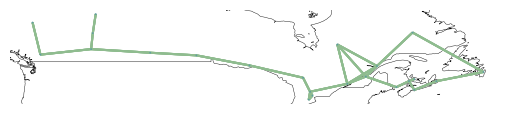

In [8]:
path = r'C:\Users\ndematos\Downloads\MMCF\CER'
df = pd.DataFrame()
for dir in os.listdir(path):
    if '.csv' in dir:
        #result_path = os.path.join(path, dir, 'Output', 'post_process_planning', 'Nodal_summary_planning.csv')
        result_path = os.path.join(path, dir)
        data = pd.read_csv(result_path)
        data = data[['Model', 'Scenario', 'Region', 'Time', 'Variable', 'Value']]
        #data.loc[:, 'Scenario'] = dir
        df = pd.concat([df, data])

In [11]:
df['Variable'] = df.Variable.str.split('|')

In [ ]:
df[]

,Model,Scenario,Region,Time,Variable,Value
0,NATEM-POWER,CER,AB,1/1/2035 0:00,"[Dispatch, Electricity, Biomass, w/o CCS]",229.3230
1,NATEM-POWER,CER,AB,1/1/2035 0:00,"[Dispatch, Electricity, Gas, Conventional Fuel...",0.0116
2,NATEM-POWER,CER,AB,1/1/2035 0:00,"[Dispatch, Electricity, Gas, Conventional Fuel...",3076.3059
3,NATEM-POWER,CER,AB,1/1/2035 0:00,"[Dispatch, Electricity, Gas, Conventional Fuel...",702.6107
4,NATEM-POWER,CER,AB,1/1/2035 0:00,"[Dispatch, Electricity, Gas, RNG, Centralized,...",1.6029
...,...,...,...,...,...,...
333184,Sutubra-TEMOA,CER,NS,2050,"[Qualifying Capacity, Electricity, Wind, Onshore]",2130.0000
333185,Sutubra-TEMOA,CER,ON,2050,"[Qualifying Capacity, Electricity, Wind, Onshore]",5706.0000
333186,Sutubra-TEMOA,CER,PE,2050,"[Qualifying Capacity, Electricity, Wind, Onshore]",1324.0000
333187,Sutubra-TEMOA,CER,QC,2050,"[Qualifying Capacity, Electricity, Wind, Onshore]",15453.0000
